# Payne Zero from stellar labels to observed spectra

This notebook builds one forward-modeling workflow in stages. We first synthesize spectra directly from stellar labels, then distinguish the fast initialized atmosphere used during exploration from the converged physical atmosphere used for a final calculation. We next apply velocity, broadening, a line-spread function, and detector sampling. The same interfaces are then used to recover a mock label, calibrate an atomic transition against a real solar FTS atlas, and model an APOGEE spectrum.

Each section introduces one new operation and reuses the object produced in the preceding section. The examples use short wavelength intervals so they remain practical on a laptop. CUDA is preferred for wide production windows, Apple Metal provides a useful local path, and every calculation also supports a CPU.


In [1]:
from pathlib import Path
import json
import os

repo = Path.cwd().resolve()
output_dir = repo / "tutorial_output"
output_dir.mkdir(exist_ok=True)
os.environ.setdefault(
    "PAYNE_ZERO_SYNTHESIS_CACHE_DIR",
    str(output_dir / "synthesis_source_cache"),
)
os.environ.setdefault(
    "PAYNE_ZERO_NUMBA_CACHE_DIR",
    str(output_dir / "numba_cache"),
)

import matplotlib.pyplot as plt
import numpy as np
import torch

requested = os.getenv("PAYNE_ZERO_DEVICE", "auto")
if requested == "auto":
    device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "cpu"
    )
else:
    device = requested
dtype_name = "float64" if device == "cpu" else "float32"
torch_dtype = torch.float64 if dtype_name == "float64" else torch.float32

COLORS = {
    "black": "#111827",
    "navy": "#1B4965",
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "grey": "#6B7280",
    "light": "#DDE6EF",
    "uncertainty": "#B8CCE0",
}
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "font.size": 10.5,
        "axes.labelsize": 10.5,
        "axes.titlesize": 10.5,
        "legend.fontsize": 9.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.55,
        "xtick.direction": "out",
        "ytick.direction": "out",
    }
)
print(f"device={device}, dtype={dtype_name}")


device=mps, dtype=float32


## 1. Synthesize directly from stellar labels

`synthesize_from_labels` is the usual entry point when no atmosphere file is available. It maps the requested labels to an initialized depth structure, reconstructs the populations needed by synthesis, and returns an intrinsic spectrum. Three initializer families cover common chemical parameterizations:

| Family | Chemical coordinates | Typical use |
|---|---|---|
| Five label | `[M/H]`, `[alpha/M]` | A compact survey search |
| Eight label | `[M/H]`, `[alpha/M]`, `[C/M]`, `[N/M]`, `[O/M]` | Giants or analyses that require an independent CNO balance |
| Direct abundance | `[Fe/H]` and selected `[X/H]` values | A many-element mixture without bulk metal or alpha coordinates |

The calculation below is the fast synthesis-only mode. It uses the initialized atmosphere but does not run the iterative atmosphere solver. Section 2 shows how to obtain and use the converged physical atmosphere at the same labels.


In [2]:
from payne_zero_synthesis import synthesize_from_labels

common_giant = dict(
    effective_temperature=4600.0,
    log_surface_gravity=2.2,
    microturbulence_km_s=1.6,
    wavelength_start_nm=1567.75,
    wavelength_end_nm=1568.65,
    r_grid=180_000,
    device=device,
    dtype=dtype_name,
)
five_label = synthesize_from_labels(
    metallicity=-0.4,
    alpha_enhancement=0.2,
    **common_giant,
)
eight_label = synthesize_from_labels(
    metallicity=-0.4,
    alpha_enhancement=0.2,
    c_over_m=-0.25,
    n_over_m=0.35,
    o_over_m=0.15,
    **common_giant,
)
direct = synthesize_from_labels(
    fe_over_h=-0.4,
    x_over_h={"C": -0.65, "N": -0.05, "O": -0.25, "Mg": -0.15},
    initializer_family="direct_abundance",
    **common_giant,
)

for result in (five_label, eight_label, direct):
    print(
        f"{result.initializer_family:18s} "
        f"{result.wavelength_nm.size:4d} pixels, "
        f"{result.seconds:.2f} s total, "
        "atmosphere=initialized (synthesis only)"
    )


five_label          103 pixels, 9.80 s total, atmosphere=initialized (synthesis only)
cno8                103 pixels, 5.48 s total, atmosphere=initialized (synthesis only)
direct_abundance    103 pixels, 5.01 s total, atmosphere=initialized (synthesis only)


All three calls use the same stellar parameters and wavelength grid. Only the chemical parameterization changes. The upper panel therefore shows nearly coincident spectra, while the lower panel makes the smaller differences relative to the five-label result visible. These changes include both the abundance-dependent line opacity and the response of the initialized atmosphere.

Use the five-label family for a compact search, the eight-label family when CNO must vary independently, and the direct family for individual abundances. In every case the returned structure is an initializer. It becomes a final physical atmosphere only after the iteration described next.


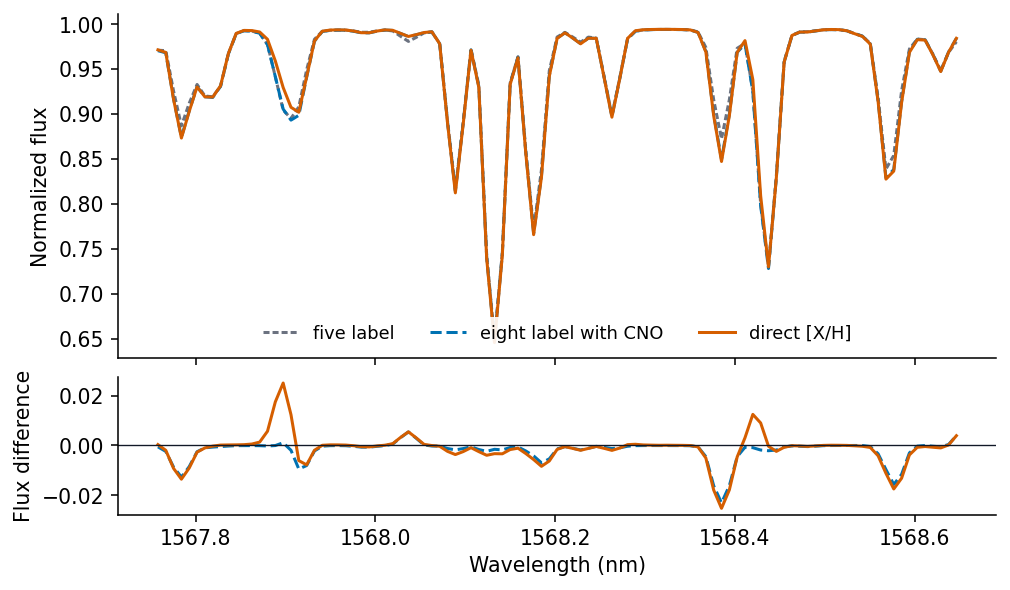

In [3]:
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 4.1),
    sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1.0]},
    constrained_layout=True,
)
for result, label, color, style in (
    (five_label, "five label", COLORS["grey"], (0, (2, 1))),
    (eight_label, "eight label with CNO", COLORS["blue"], "--"),
    (direct, "direct [X/H]", COLORS["orange"], "-"),
):
    top.plot(
        result.wavelength_nm,
        result.normalized_flux,
        label=label,
        color=color,
        linestyle=style,
    )
bottom.plot(
    eight_label.wavelength_nm,
    eight_label.normalized_flux - five_label.normalized_flux,
    color=COLORS["blue"],
    linestyle="--",
    label="eight label minus five label",
)
bottom.plot(
    direct.wavelength_nm,
    direct.normalized_flux - five_label.normalized_flux,
    color=COLORS["orange"],
    label="direct minus five label",
)
bottom.axhline(0.0, color=COLORS["black"], lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Flux difference")
top.legend(
    loc="lower center",
    ncol=3,
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
plt.show()


## 2. Initialized and converged atmospheres

The initialized structure makes nearby spectral evaluations inexpensive, but it is not yet the solution of the atmosphere equations at the requested labels. The atmosphere solver repeatedly updates the equation of state, opacity, radiation field, pressure, and temperature until its convergence tests pass. Synthesis can then consume the converged structure through the same array interface used above.

To keep the notebook short, this section loads the bundled converged solar atmosphere and compares it with the initialized solar structure. Set `PAYNE_ZERO_RUN_ATMOSPHERE=1` to repeat the physical atmosphere calculation. The resulting archive is interchangeable with any other converged atmosphere product accepted by `synthesize`.


In [4]:
from payne_zero_atmosphere import solve_structured_atmosphere
from payne_zero_synthesis import synthesize

physical_path = repo / "examples" / "data" / "sun_structured_atmosphere.npz"
if os.getenv("PAYNE_ZERO_RUN_ATMOSPHERE", "0") == "1":
    physical_path = solve_structured_atmosphere(
        effective_temperature=5777.0,
        log_surface_gravity=4.44,
        metallicity=0.0,
        alpha_enhancement=0.0,
        microturbulence_km_s=1.0,
        out_dir=output_dir / "solar_atmosphere",
    )

solar_common = dict(
    wavelength_start_nm=500.0,
    wavelength_end_nm=502.0,
    device=device,
    dtype=dtype_name,
)
initialized_sun = synthesize_from_labels(
    effective_temperature=5777.0,
    log_surface_gravity=4.44,
    metallicity=0.0,
    alpha_enhancement=0.0,
    microturbulence_km_s=1.0,
    r_grid=60_000,
    **solar_common,
)
physical_sun = synthesize(
    physical_path,
    resolution=60_000,
    **solar_common,
)
print("fast spectrum: initialized atmosphere (synthesis only)")
print("final spectrum: converged atmosphere", physical_path.name)


fast spectrum: initialized atmosphere (synthesis only)
final spectrum: converged atmosphere sun_structured_atmosphere.npz


The two spectra contain the same broad line pattern because they share the requested stellar labels and line catalog. Their individual line depths can differ because physical atmosphere iteration changes the depth-dependent temperature, pressure, populations, and opacity. The lower panel plots initialized minus converged flux, so zero would indicate identical spectra.

This distinction sets the pattern used later by the fitter. The initialized atmosphere supplies fast trial spectra. A converged atmosphere is calculated at the selected labels when the application requires a physically closed final model. Saved products retain this role explicitly so an initialized structure is not mistaken for a converged one.


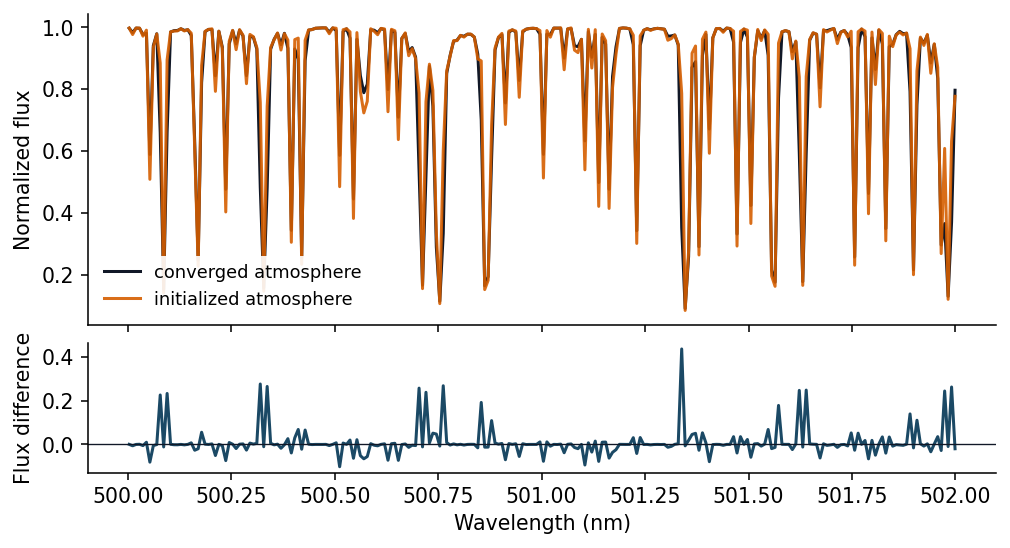

In [5]:
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["black"],
    label="converged atmosphere",
)
top.plot(
    initialized_sun.wavelength_nm,
    initialized_sun.normalized_flux,
    color=COLORS["orange"],
    alpha=0.9,
    label="initialized atmosphere",
)
difference = initialized_sun.normalized_flux - physical_sun.normalized_flux
bottom.plot(physical_sun.wavelength_nm, difference, color=COLORS["navy"])
bottom.axhline(0.0, color=COLORS["black"], lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Flux difference")
top.legend(
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
plt.show()


## 3. Map an intrinsic spectrum to observed pixels

Synthesis returns total and continuum flux on a uniform logarithmic wavelength grid. A reduced observation instead lives on detector pixels and includes a radial-velocity shift, stellar or residual broadening, and an instrumental line-spread function. These operations must be applied consistently before the model is sampled at the observed wavelengths.

`ObservedSpectrumOperator` performs this complete projection on the same Torch device as synthesis. It convolves total and continuum flux separately and normalizes only afterward, which avoids treating a varying continuum as part of the line-spread function. The example uses a constant resolving power. Section 6 replaces it with APOGEE's wavelength-dependent LSF through the same `convolve_fluxes` interface.


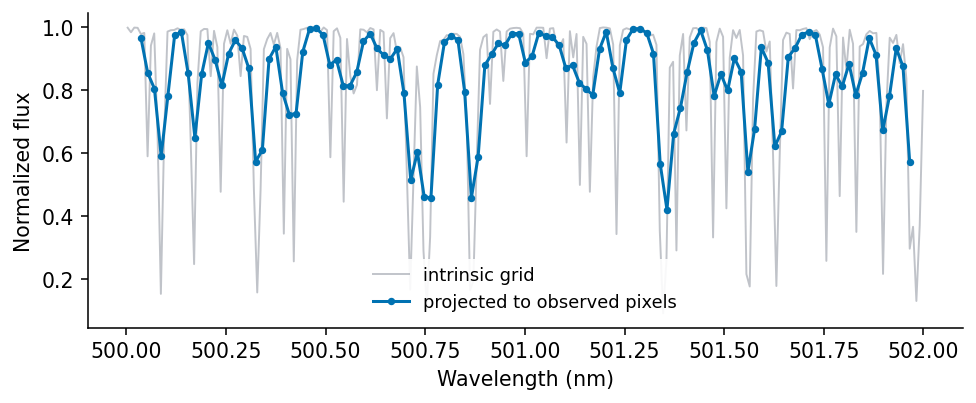

In [6]:
from fitter import ObservedSpectrumOperator

observed_wavelength = np.linspace(
    physical_sun.wavelength_nm[4],
    physical_sun.wavelength_nm[-5],
    115,
)
instrument = ObservedSpectrumOperator(
    physical_sun.wavelength_nm,
    observed_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)
instrument.set_parameters(
    radial_velocity_km_s=2.0,
    broadening_sigma_km_s=3.0,
)
projected_total, projected_continuum, projected_normalized = (
    instrument.convolve_fluxes(
        torch.as_tensor(
            physical_sun.flux_total, device=device, dtype=torch_dtype
        ),
        torch.as_tensor(
            physical_sun.flux_continuum, device=device, dtype=torch_dtype
        ),
    )
)
projected_normalized = projected_normalized.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(7.1, 3.0))
ax.plot(
    physical_sun.wavelength_nm,
    physical_sun.normalized_flux,
    color=COLORS["grey"],
    alpha=0.42,
    linewidth=1.0,
    label="intrinsic grid",
)
ax.plot(
    observed_wavelength,
    projected_normalized,
    color=COLORS["blue"],
    marker="o",
    ms=2.8,
    label="projected to observed pixels",
)
ax.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
ax.legend(
    loc="lower center",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
fig.tight_layout()
plt.show()


## 4. Recover a label from a mock spectrum

A spectral fitter needs three pieces: the observed flux and uncertainty, bounds for the labels being varied, and a callback that returns the forward model at a proposed label vector. Here both the mock observation and every trial spectrum come directly from `synthesize_from_labels` followed by the instrument operator from Section 3. No label-to-flux emulator enters the fit.

The callback below varies `[M/H]`. The fitter measures a local spectral response with finite differences, proposes a bounded label update, and repeats until the objective no longer improves. Extending the fit to several labels changes the parameter vector and response steps, not the forward-model interface.

This controlled example is already continuum normalized, so no continuum coefficients are fitted. For a reduced spectrum, pass a low-order basis through `continuum_basis`; those linear coefficients are then profiled at every nonlinear trial.


In [7]:
from fitter import (
    FitConfiguration,
    NormalizedSpectrum,
    fit_normalized_spectrum,
)

mock_common = dict(
    effective_temperature=4750.0,
    log_surface_gravity=2.5,
    alpha_enhancement=0.15,
    microturbulence_km_s=1.5,
    wavelength_start_nm=515.0,
    wavelength_end_nm=517.0,
    r_grid=30_000,
    device=device,
    dtype=dtype_name,
)
native_template = synthesize_from_labels(metallicity=-0.3, **mock_common)
mock_wavelength = np.linspace(
    native_template.wavelength_nm[3],
    native_template.wavelength_nm[-4],
    120,
)
mock_instrument = ObservedSpectrumOperator(
    native_template.wavelength_nm,
    mock_wavelength,
    resolving_power=25_000,
    device=device,
    dtype=torch_dtype,
)

def metallicity_model(parameters):
    return synthesize_from_labels(
        metallicity=float(parameters[0]),
        spectral_operator=mock_instrument,
        **mock_common,
    ).normalized_flux

truth_metallicity = -0.30
noiseless_mock = metallicity_model(np.array([truth_metallicity]))
rng = np.random.default_rng(20260724)
sigma = 1.0 / 400.0
observed_mock = noiseless_mock + rng.normal(0.0, sigma, noiseless_mock.size)
mock_data = NormalizedSpectrum(
    wavelength=mock_wavelength,
    flux=observed_mock,
    inverse_variance=np.full(mock_wavelength.size, sigma**-2),
    mask=np.ones(mock_wavelength.size, dtype=bool),
)
fit_config = FitConfiguration(
    names=("M_H",),
    initial=np.array([-0.05]),
    lower=np.array([-1.0]),
    upper=np.array([0.3]),
    derivative_steps=np.array([0.05]),
    trust_half_width=np.array([0.30]),
    maximum_iterations=4,
)
mock_fit = fit_normalized_spectrum(
    mock_data,
    fit_config,
    metallicity_model,
)
print(f"truth [M/H] = {truth_metallicity:+.3f}")
print(f"fitted [M/H] = {mock_fit.parameters[0]:+.3f}")
print(f"stop = {mock_fit.stop_reason}")


truth [M/H] = -0.300
fitted [M/H] = -0.295
stop = line_search


The upper panel compares the recovered spectrum with the noisy mock observation. The lower panel shows data minus model together with the known one-sigma noise band. Residuals that fluctuate within this band indicate that the recovered spectrum explains the mock data to the injected precision.


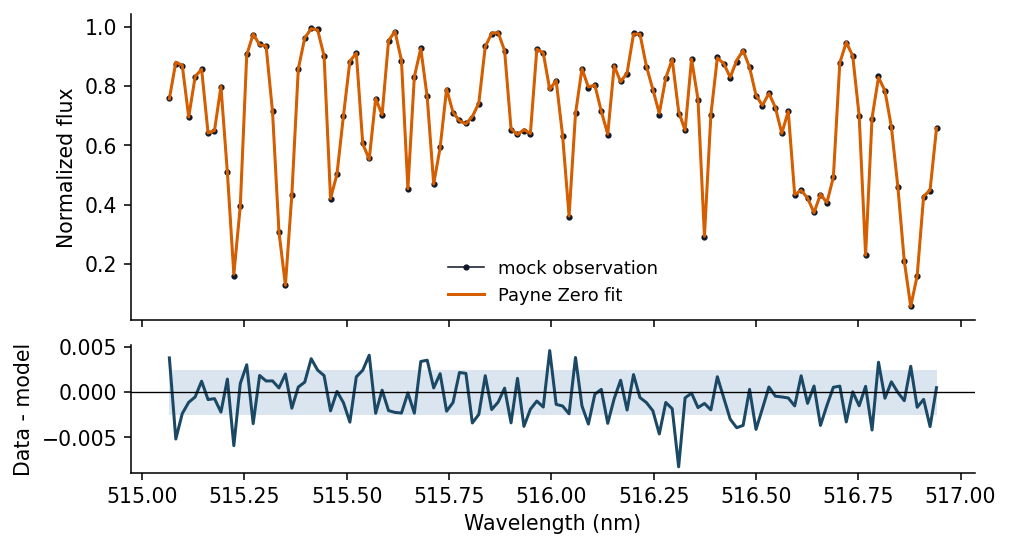

In [8]:
fit_residual = observed_mock - mock_fit.model_flux
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 3.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    mock_wavelength,
    observed_mock,
    color=COLORS["black"],
    marker="o",
    markersize=2.2,
    linewidth=0.8,
    label="mock observation",
)
top.plot(
    mock_wavelength,
    mock_fit.model_flux,
    color=COLORS["orange"],
    label="Payne Zero fit",
)
bottom.plot(mock_wavelength, fit_residual, color=COLORS["navy"])
bottom.fill_between(
    mock_wavelength,
    -sigma,
    sigma,
    color=COLORS["uncertainty"],
    alpha=0.5,
    linewidth=0,
    label="1 sigma uncertainty",
)
bottom.axhline(0.0, color="black", lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength (nm)", ylabel="Data - model")
top.legend(
    loc="lower center",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
plt.show()


## 5. Calibrate an atomic line with a real FTS spectrum

A line-list calibration asks whether a mismatch can be reduced by changing an atomic parameter rather than a stellar label. The standard-star atmosphere, wavelength registration, broadening, and all unselected opacity remain fixed. The optimizer differentiates the synthesized flux with respect to the selected atomic parameters and updates them jointly with the transfer calculation.

The bundled example uses the Livingston and Wallace solar Fourier-transform-spectrometer atlas and one Fe I transition at 1568.180 nm. It begins from the unmodified catalog value and fits a single additive correction to `log(gf)`, the logarithmic oscillator strength that controls the line opacity. The expensive background opacity is prepared once; each optimizer step recalculates only the selected transition and the emergent spectrum.


In [9]:
from linelist_calibration import calibrate_line_parameters
from linelist_calibration.examples.fit_solar_fts_line import build_example

fts_data, fts_config, fts_model, fts_metadata = build_example(
    device=device,
    dtype=dtype_name,
    maximum_iterations=30,
)
fts_callback = fts_model.callback(("loggf",))
fts_baseline = fts_model.baseline_flux(("loggf",))
fts_result = calibrate_line_parameters(
    fts_data,
    fts_config,
    fts_callback,
)
fitted_tensor = torch.as_tensor(
    fts_result.values,
    device=fts_model.device,
    dtype=fts_model.dtype,
)
with torch.no_grad():
    fts_calibrated = fts_callback(fitted_tensor).detach().cpu().numpy()
fts_overlay = fts_model.write_atomic_calibration_overlay(
    fts_result.values,
    output_dir / "solar_fts_fe_line_overlay.npz",
    parameter_families=("loggf",),
    calibration_name="tutorial_solar_fts_fe_line",
)
residual_power_reduction = 1.0 - (
    fts_result.final_loss / fts_result.initial_loss
)
print("atlas:", fts_metadata["atlas"])
print("transition:", fts_model.transitions[0].name)
print(f"fitted delta log(gf) = {fts_result.values[0]:+.3f} dex")
print(f"full-window residual-power reduction = {100 * residual_power_reduction:.1f}%")
print("overlay:", fts_overlay["overlay_path"])


atlas: Livingston & Wallace (1991) solar center-of-disk infrared atlas
transition: Fe I 1568.180 nm
fitted delta log(gf) = +0.801 dex
full-window residual-power reduction = 78.5%
overlay: /Users/ysting/payne-zero/tutorial_output/solar_fts_fe_line_overlay.npz


The figure focuses on the central 0.06 nm interval where the selected Fe I transition controls the response. Neighboring blends outside this interval are intentionally omitted because a one-line calibration cannot change them. The dashed blue curve is the original catalog prediction and the orange curve uses the fitted oscillator strength. The residual panel makes the improvement easier to judge than the overlaid line profiles alone.

The saved overlay records the transition identity and its additive correction in dex. A production calibration can optimize several linked transitions and the damping families `vdw`, `radiative`, and `stark`. Replacing the standard requires a converged atmosphere, an observed wavelength and flux array, objective weights, velocity registration, and a broadening or LSF kernel. Joint calibration concatenates several standards so the same atomic correction must explain each atmosphere.


line-core residual-power reduction = 99.4%


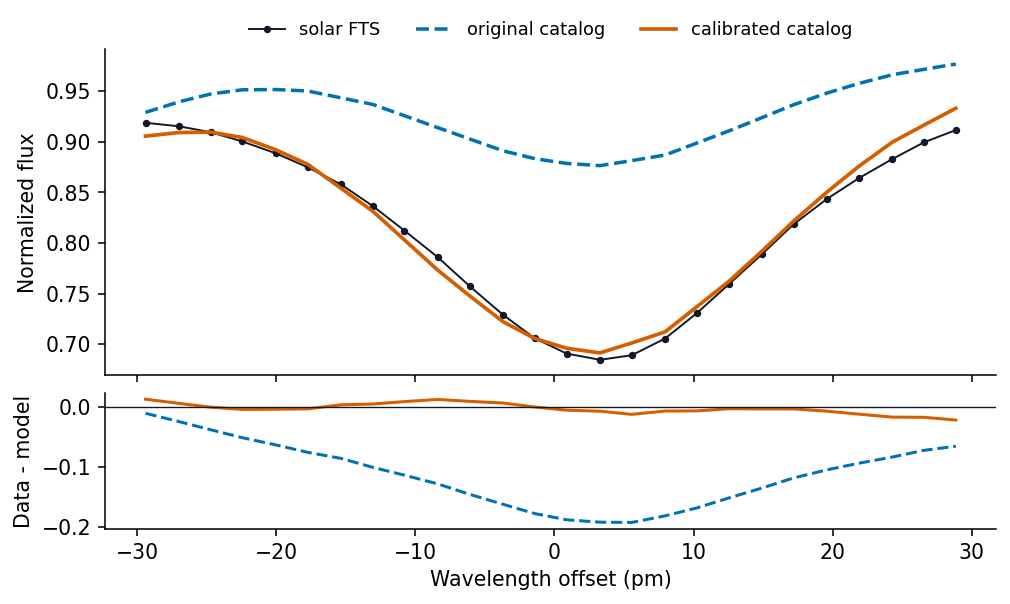

In [10]:
fts_wavelength = fts_model.output_wavelength_nm
fts_observed = np.asarray(fts_data.flux)
fts_delta_pm = 1000.0 * (
    fts_wavelength - fts_model.transitions[0].wavelength_nm
)
line_core = np.abs(fts_delta_pm) <= 30.0
core_initial = np.sum(
    fts_data.weight[line_core]
    * (fts_observed[line_core] - fts_baseline[line_core]) ** 2
)
core_final = np.sum(
    fts_data.weight[line_core]
    * (fts_observed[line_core] - fts_calibrated[line_core]) ** 2
)
core_reduction = 1.0 - core_final / core_initial
print(f"line-core residual-power reduction = {100 * core_reduction:.1f}%")
fig, (top, bottom) = plt.subplots(
    2,
    1,
    figsize=(7.1, 4.2),
    sharex=True,
    gridspec_kw={"height_ratios": [2.4, 1.0]},
    constrained_layout=True,
)
top.plot(
    fts_delta_pm[line_core],
    fts_observed[line_core],
    color=COLORS["black"],
    marker="o",
    markersize=2.8,
    linewidth=1.0,
    label="solar FTS",
)
top.plot(
    fts_delta_pm[line_core],
    fts_baseline[line_core],
    color=COLORS["blue"],
    linestyle="--",
    linewidth=1.8,
    label="original catalog",
)
top.plot(
    fts_delta_pm[line_core],
    fts_calibrated[line_core],
    color=COLORS["orange"],
    linewidth=1.9,
    label="calibrated catalog",
)
bottom.plot(
    fts_delta_pm[line_core],
    (fts_observed - fts_baseline)[line_core],
    color=COLORS["blue"],
    linestyle="--",
    label="original residual",
)
bottom.plot(
    fts_delta_pm[line_core],
    (fts_observed - fts_calibrated)[line_core],
    color=COLORS["orange"],
    label="calibrated residual",
)
bottom.axhline(0.0, color=COLORS["black"], lw=0.7)
top.set_ylabel("Normalized flux")
bottom.set(xlabel="Wavelength offset (pm)", ylabel="Data - model")
top.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=3,
    frameon=False,
    borderaxespad=0.0,
)
plt.show()


## 6. APOGEE with a wavelength-dependent LSF and continuum

A survey adapter supplies the observational details that are absent from an intrinsic spectrum. APOGEE uses a wavelength-dependent line-spread function, so the constant-resolution operator from Section 3 is replaced by compact kernels tabulated across the detector. The implementation keeps these kernels on the selected device and convolves total and continuum flux consistently before normalization.

The APOGEE forward model also fits a residual velocity, an effective Gaussian broadening, and one low-order continuum per detector segment. These are nuisance parameters rather than changes to the stellar atmosphere. They remain inside the forward calculation so every trial is compared with the reduced spectrum on its native pixels.

The cells below load one public DR14 example and a prepared result generated by `fit_apogee_spectrum`. This makes the default notebook immediate and reproducible. Set `PAYNE_ZERO_RUN_APOGEE=1` to repeat the full optimization before plotting; a CPU run is expected to be slower than loading the retained fit.


In [11]:
from fitter.apogee import fit_apogee_spectrum

with np.load(repo / "examples" / "data" / "apogee_dr14_example.npz") as source:
    apogee = {name: np.asarray(source[name]) for name in source.files}
apogee_metadata = json.loads(
    (repo / "examples" / "data" / "apogee_dr14_example.json").read_text()
)
with np.load(
    repo / "examples" / "data" / "apogee_dr14_fit_reference.npz"
) as source:
    apogee_reference = {
        name: np.asarray(source[name]) for name in source.files
    }

if os.getenv("PAYNE_ZERO_RUN_APOGEE", "0") == "1":
    fit_apogee_spectrum(
        output_dir / "apogee_fit",
        object_id=apogee_metadata["object_id"],
        wavelength_nm=apogee["wavelength_nm"],
        normalized_flux=apogee["normalized_flux"],
        inverse_variance=apogee["inverse_variance"],
        good_pixel_mask=apogee["good_pixel_mask"],
        reference_labels=np.array(
            [
                apogee_metadata["effective_temperature"],
                apogee_metadata["log_surface_gravity"],
                apogee_metadata["metallicity"],
                apogee_metadata["alpha_enhancement"],
                apogee_metadata["microturbulence_km_s"],
            ]
        ),
        reference_vmacro_km_s=apogee_metadata[
            "macroscopic_broadening_km_s"
        ],
        atomic_calibration_path=(
            repo
            / "linelist_calibration"
            / "data"
            / "sun_arcturus_fts_hband_shared.npz"
        ),
        device=device,
        dtype=dtype_name,
        force=True,
    )

fit_metadata = json.loads(str(apogee_reference["metadata_json"]))
print(apogee_metadata["object_id"])
print(fit_metadata["instrument_operator"])


2M08002084+4044415
APOGEE DR14 all-slit mean line-spread function


The left panel shows the measured LSF at three wavelengths. Their widths and asymmetries change across the APOGEE band, which is why a single Gaussian resolution is insufficient for this example. The right panel compares the reduced APOGEE spectrum with the continuum-profiled and LSF-convolved Payne Zero model over a line-rich interval. Points and connecting lines identify the observed pixels, while the orange curve is the forward model evaluated on exactly those pixels.

The separate residual panel uses the same model and the reported one-sigma flux uncertainty. Structure well outside that band can indicate imperfect stellar labels, line data, continuum treatment, or an instrument mismatch; the adapter makes each of those components explicit rather than absorbing them into a spectral emulator.


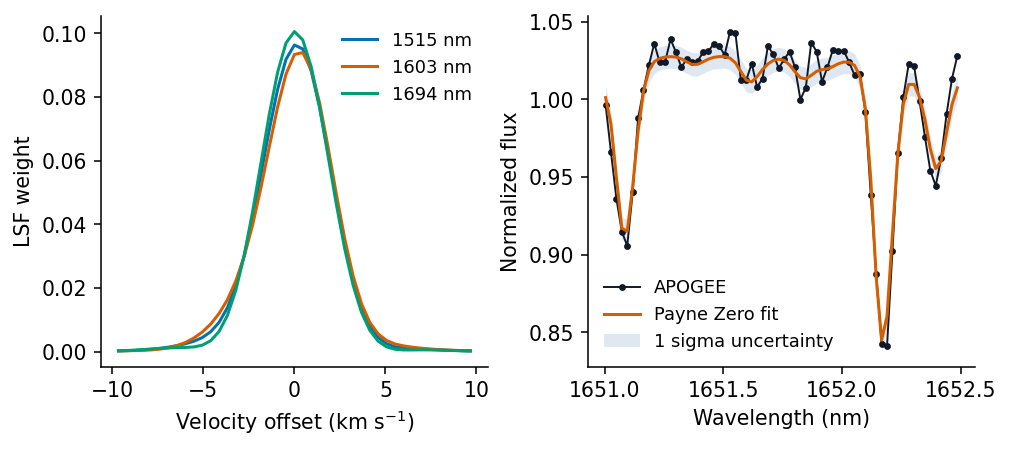

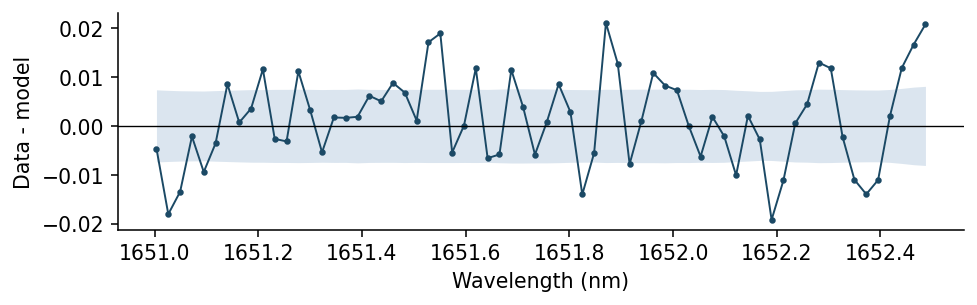

In [12]:
with np.load(
    repo / "fitter" / "apogee" / "data" / "apogee_dr14_combo_lsf.npz"
) as lsf_asset:
    taps = np.asarray(lsf_asset["tap_offset_oversampled_pixel"], np.float64)
    kernels = np.asarray(lsf_asset["kernel_weights"], np.float64)
    lsf_wavelength = np.asarray(lsf_asset["wavelength_nm"], np.float64)
tap_velocity = taps * (np.log(10.0) * 2.0e-6 / 3.0) * 299_792.458

wavelength = apogee["wavelength_nm"]
observed = apogee["normalized_flux"]
error = apogee["normalized_error"]
model = apogee_reference["normalized_model_flux"]
good = apogee["good_pixel_mask"]
region = (wavelength > 1651.0) & (wavelength < 1652.5) & good

fig, (left, right) = plt.subplots(
    1,
    2,
    figsize=(7.1, 3.1),
    constrained_layout=True,
)
for index, color in zip(
    (0, len(lsf_wavelength) // 2, -1),
    (COLORS["blue"], COLORS["orange"], COLORS["green"]),
):
    left.plot(
        tap_velocity,
        kernels[index],
        color=color,
        label=f"{lsf_wavelength[index]:.0f} nm",
    )
left.set(xlabel="Velocity offset (km s$^{-1}$)", ylabel="LSF weight")
left.legend(loc="upper right", frameon=False)

right.plot(
    wavelength[region],
    observed[region],
    color=COLORS["black"],
    marker="o",
    markersize=2.5,
    linewidth=1.0,
    label="APOGEE",
)
right.plot(
    wavelength[region],
    model[region],
    color=COLORS["orange"],
    label="Payne Zero fit",
)
right.fill_between(
    wavelength[region],
    model[region] - error[region],
    model[region] + error[region],
    color=COLORS["uncertainty"],
    alpha=0.45,
    linewidth=0,
    label="1 sigma uncertainty",
)
right.set(xlabel="Wavelength (nm)", ylabel="Normalized flux")
right.legend(
    loc="lower left",
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.9,
)
plt.show()

residual = observed[region] - model[region]
fig, ax = plt.subplots(figsize=(7.1, 2.3))
ax.plot(
    wavelength[region],
    residual,
    color=COLORS["navy"],
    marker="o",
    markersize=2.3,
    linewidth=1.0,
    label="data minus model",
)
ax.fill_between(
    wavelength[region],
    -error[region],
    error[region],
    color=COLORS["uncertainty"],
    alpha=0.5,
    linewidth=0,
    label="1 sigma uncertainty",
)
ax.axhline(0.0, color="black", lw=0.7)
ax.set(xlabel="Wavelength (nm)", ylabel="Data - model")
fig.tight_layout()
plt.show()


## 7. Adapting the workflow

The examples above share one separation of responsibilities. Stellar labels define the atmosphere and opacity. The instrument operator maps the intrinsic total and continuum flux to observed pixels. The fitter supplies the objective and proposes new labels. Line calibration instead keeps the stellar state fixed and varies selected atomic parameters.

To fit another reduced spectrum, keep the label callback and replace the wavelength, flux, uncertainty, mask, and instrument operator. A constant-resolution survey can use `ObservedSpectrumOperator`. A wavelength-dependent LSF implements `output_wavelength_nm` and `convolve_fluxes(total_flux, continuum_flux)`. Supply a low-order basis only when the reduction still requires continuum profiling.

To calibrate another standard star, construct `SynthesisLineCalibrationModel` with its converged atmosphere and atlas arrays, choose the transitions and parameter families, optimize, and export the correction overlay or a substituted local catalog. Several standard-star callbacks can be concatenated so one correction must explain each atmosphere.

For fast local exploration, use spectra generated from an initialized atmosphere. When atmospheric consistency matters for the retained result, converge the atmosphere at the selected labels and synthesize again. Both paths use the same synthesis and instrument interfaces, so the transition from a quick search to the final physical calculation remains explicit.
